# Chaîne de prétraitement MGB-SA — du MNT aux minibacias

**Projet** : transport de sédiments en suspension dans le bassin du Magdalena (Colombie) avec MGB-SED.
Ce notebook reproduit **à la main, en Python simple**, ce que fait le plugin *IPH-HydroTools* de QGIS pour
transformer un Modèle Numérique de Terrain (MNT / DEM) en structure hydrologique exploitable par MGB.

But : **comprendre les maths de chaque transformation**, pas remplacer IPH-HydroTools.

> **Portée — à lire avant de citer quoi que ce soit de ce notebook (note datée 2026-08-19).**
> Ce notebook est **didactique** : il dérive la chaîne à la main sur une grille-jouet 6×6 et ne produit **aucun
> fichier lu par le modèle**. La délinéation **réelle** n'a **pas** été faite avec IPH-HydroTools : elle est faite
> en **Python pur** (`pyflwdir` + `rasterio`) dans `notebooks/07_preprocessing_minibacias.ipynb`, sur le MNT
> **Copernicus GLO-90 (COP90)**, et livre `data/processed/minibacias.csv` — **8,672 minibacias, 257,096.93 km²**,
> colonnes `id, area_km2, downstream`. C'est ce fichier, et non un `mini.gtb`, que lisent `src/mgb_hydrology.py`
> (`build_topology`) et `src/mgb_sediment.py`. Le vocabulaire IPH-HydroTools ci-dessous reste **exact comme
> description des étapes** — c'est pourquoi il est conservé — mais il ne nomme pas l'outil qui a produit le modèle.
> Chaîne réellement suivie : **01 (jouet) → 07 (délinéation) → 08 (URH) → 09 (paramètres sol) → 12/13/14
> (assemblage, run, calage H2E) → 18/19 (MUSLE, porte C3 / entrée C4)**.
On travaille sur un mini-DEM 6×6 qu'on peut vérifier à la main ; à la fin, on explique comment
remplacer ce DEM-jouet par le vrai MNT du Magdalena.

**La chaîne, dans l'ordre :**

| Étape | Nom (IPH-HydroTools) | Ce qu'elle produit |
|------|----------------------|--------------------|
| 1 | MNT + format `.asc` | la matrice d'altitudes + son en-tête géoréférencé |
| 2 | Sink and Destroy | un MNT sans cuvette (l'eau peut partout s'écouler) |
| 3 | Flow Direction | pour chaque cellule, la voisine vers laquelle l'eau part |
| 4 | Flow Accumulation | l'aire drainée (nb de cellules amont) par cellule |
| 5 | Stream Definition | le réseau de rivières (seuil sur l'accumulation) |
| 6 | Stream Segmentation | le découpage du réseau en tronçons |
| 7 | Watershed / Catchment | les **minibacias**, unités de calcul du MGB |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration commune ---
cellsize = 30.0                 # taille de cellule au sol (m), ex. GLO-30 / ALOS World 3D
diag = cellsize * (2 ** 0.5)    # distance diagonale = cellsize * racine(2)

# Les 8 voisins : (decalage_ligne, decalage_colonne, distance, code_direction)
# Codes facon ArcGIS :  E=1  SE=2  S=4  SO=8  O=16  NO=32  N=64  NE=128
voisins = [
    (0,  1, cellsize,   1),   # Est
    (1,  1, diag,       2),   # Sud-Est
    (1,  0, cellsize,   4),   # Sud
    (1, -1, diag,       8),   # Sud-Ouest
    (0, -1, cellsize,  16),   # Ouest
    (-1,-1, diag,      32),   # Nord-Ouest
    (-1, 0, cellsize,  64),   # Nord
    (-1, 1, diag,     128),   # Nord-Est
]
# passage inverse : d'un code de direction vers le decalage (ligne, colonne)
code_to_off = {1:(0,1),2:(1,1),4:(1,0),8:(1,-1),16:(0,-1),32:(-1,-1),64:(-1,0),128:(-1,1)}

def montre(grille, titre, cmap="terrain", entiers=True):
    """Affiche une grille avec la valeur ecrite dans chaque case."""
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(grille, cmap=cmap)
    for (i, j), v in np.ndenumerate(grille):
        txt = str(int(v)) if entiers else f"{v:.2f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=10, fontweight="bold")
    ax.set_xticks(range(grille.shape[1])); ax.set_yticks(range(grille.shape[0]))
    ax.set_xlabel("col (j)"); ax.set_ylabel("row (i)"); ax.set_title(titre)
    plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()


## Étape 1 — Le MNT comme matrice, et le format `.asc`

Un MNT n'est qu'une **matrice de nombres** : chaque case est un pixel carré de côté `cellsize`, sa valeur est l'altitude.
Toute la géographie tient dans deux choses : la valeur (altitude) et la position `(i, j)`.

Pour passer des indices à de vraies coordonnées, on utilise le format **ESRI ASCII grid (`.asc`)** :
6 lignes d'en-tête puis la matrice brute.

```
ncols        6
nrows        6
xllcorner    <X du coin inférieur gauche>
yllcorner    <Y du coin inférieur gauche>
cellsize     <taille de cellule>
NODATA_value -9999
```

Deux conséquences du `cellsize` qui reviennent partout : **aire d'une cellule = cellsize²** (pour MUSLE),
et **distance diagonale = cellsize·√2** (cœur du calcul de pente, étape 3).

**`NODATA_value -9999`** : une grille est toujours un rectangle plein, mais la réalité (bassin découpé, bord de mer,
trou de données) ne l'est pas. On code donc les cases « vides » par un nombre spécial impossible pour une vraie altitude.
IPH-HydroTools **attend précisément -9999** : avec une autre sentinelle (souvent -32768, ou des `NaN`), le code lit ces
cases comme de vraies altitudes très négatives → l'eau y file, et le modèle plante. D'où la règle « forcer NODATA à -9999 ».

Notre cellule (2,2) = 60 est plus basse que ses 8 voisines : c'est une **cuvette**, qu'on traitera à l'étape 2.


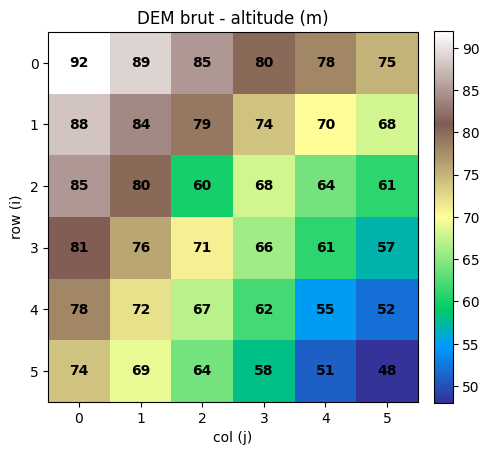

ncols        6
nrows        6
xllcorner    1000
yllcorner    2000
cellsize     30
NODATA_value -9999
92 89 85 80 78 75
88 84 79 74 70 68
85 80 60 68 64 61
81 76 71 66 61 57
78 72 67 62 55 52
74 69 64 58 51 48



In [10]:
# Notre DEM-jouet (altitude en metres). La case (2,2)=60 est une cuvette.
dem = np.array([
 [92, 89, 85, 80, 78, 75],
 [88, 84, 79, 74, 70, 68],
 [85, 80, 60, 68, 64, 61],
 [81, 76, 71, 66, 61, 57],
 [78, 72, 67, 62, 55, 52],
 [74, 69, 64, 58, 51, 48],
], dtype=float)
nrows, ncols = dem.shape

montre(dem, "DEM brut - altitude (m)")

# Ecriture d'un vrai fichier .asc (coin inferieur gauche fictif a 1000, 2000)
with open("dem.asc", "w") as f:
    f.write("ncols        %d\n" % ncols)
    f.write("nrows        %d\n" % nrows)
    f.write("xllcorner    1000\n")
    f.write("yllcorner    2000\n")
    f.write("cellsize     %d\n" % cellsize)
    f.write("NODATA_value -9999\n")
    for i in range(nrows):
        f.write(" ".join(str(int(v)) for v in dem[i]) + "\n")

print(open("dem.asc").read())


## Étape 2 — Sink and Destroy (remplissage des cuvettes)

Une **cuvette** est une cellule (ou un groupe) sans aucune voisine plus basse : l'eau y est piégée et le réseau aval est coupé.
On les comble par l'algorithme de **Planchon-Darboux** :

1. On « noie » tout l'intérieur très haut (`1e9`) ; les bords gardent leur altitude (ce sont les seules sorties).
2. On laisse l'eau **redescendre** : chaque cellule ne peut descendre que jusqu'au niveau qui lui laisse encore
   un écoulement vers une voisine déjà traitée. On répète jusqu'à stabilité.

Le paramètre **`eps`** : `eps=0` remplit *pile* au niveau de débordement → crée des zones **plates** (pente nulle) que le D8
ne saura pas router. `eps>0` (ex. 0.01 m) force une pente minuscule mais définie. **Toujours utiliser eps>0 en pratique.**


Difference (rempli - brut) : seule la cuvette (2,2) change
[[0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   6.01 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]]


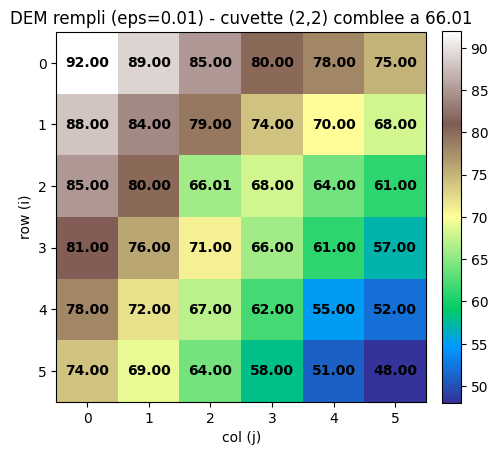

In [3]:
def remplir(dem, eps=0.01):
    W = np.zeros((nrows, ncols))
    # 1) initialisation : bords = altitude reelle, interieur = tres haut
    for i in range(nrows):
        for j in range(ncols):
            bord = (i == 0 or i == nrows-1 or j == 0 or j == ncols-1)
            W[i][j] = dem[i][j] if bord else 1e9
    # 2) relaxation jusqu'a ce que plus rien ne change
    change = True
    while change:
        change = False
        for i in range(1, nrows-1):
            for j in range(1, ncols-1):
                for (di, dj, dist, code) in voisins:
                    ni, nj = i+di, j+dj
                    if dem[i][j] >= W[ni][nj] + eps:          # une voisine assez basse -> je garde mon altitude
                        if W[i][j] != dem[i][j]:
                            W[i][j] = dem[i][j]; change = True
                        break
                    elif W[i][j] > W[ni][nj] + eps:           # encore trop haute -> je descends
                        W[i][j] = W[ni][nj] + eps; change = True
    return W

W = remplir(dem, eps=0.01)
print("Difference (rempli - brut) : seule la cuvette (2,2) change")
print(W - dem)
montre(W, "DEM rempli (eps=0.01) - cuvette (2,2) comblee a 66.01", entiers=False)


## Étape 3 — Flow Direction (D8)

Chaque cellule envoie **toute** son eau vers **une seule** voisine : celle de plus forte **pente descendante**.
Attention : la pente n'est pas le dénivelé brut mais le dénivelé **par unité de distance** :

$$\text{pente} = \frac{Z_{\text{cellule}} - Z_{\text{voisine}}}{\text{distance}}$$

où distance = `cellsize` (voisines droites) ou `cellsize·√2` (diagonales). C'est cette division qui empêche une diagonale
de « gagner » juste parce que son dénivelé brut est plus grand. On code le résultat par la direction (1,2,4,…,128).
Une case à **0** = aucune voisine plus basse → uniquement les bords/exutoire après remplissage.


Grille des directions D8 :
[[  2   2   2   2   4   4]
 [  2   2   4   2   2   4]
 [  2   1   2   2   2   4]
 [  2 128   2   2   2   4]
 [  2   2   2   2   2   4]
 [  1   1   1   1   1   0]]


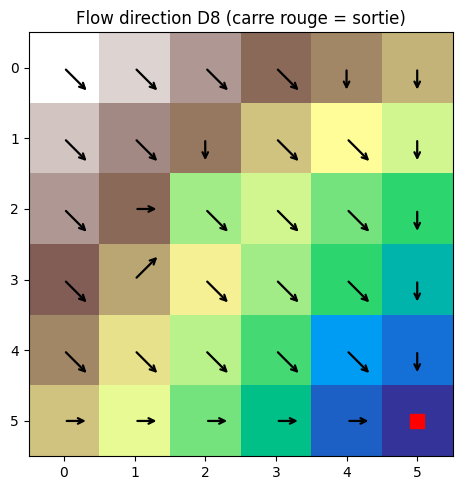

In [4]:
def downstream(i, j, d):
    """Renvoie la cellule aval (ligne, col) vers laquelle (i,j) s'ecoule, ou None."""
    k = d[i][j]
    if k == 0:
        return None
    di, dj = code_to_off[k]
    return (i+di, j+dj)

def flow_direction(Z):
    direction = np.zeros((nrows, ncols), dtype=int)
    for i in range(nrows):
        for j in range(ncols):
            meilleure_pente = 0.0     # on ne garde que les pentes strictement descendantes
            meilleur_code = 0
            for (di, dj, dist, code) in voisins:
                ni, nj = i+di, j+dj
                if 0 <= ni < nrows and 0 <= nj < ncols:
                    pente = (Z[i][j] - Z[ni][nj]) / dist
                    if pente > meilleure_pente:
                        meilleure_pente = pente
                        meilleur_code = code
            direction[i][j] = meilleur_code
    return direction

direction = flow_direction(W)
print("Grille des directions D8 :"); print(direction)

# Visualisation par fleches
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(W, cmap="terrain")
for (i, j), k in np.ndenumerate(direction):
    if k != 0:
        di, dj = code_to_off[k]
        ax.annotate("", xy=(j+dj*0.35, i+di*0.35), xytext=(j, i),
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.6))
    else:
        ax.plot(j, i, "rs", ms=10)   # exutoire / sortie
ax.set_title("Flow direction D8 (carre rouge = sortie)")
ax.set_xticks(range(ncols)); ax.set_yticks(range(nrows)); plt.tight_layout(); plt.show()


## Étape 4 — Flow Accumulation (aire drainée)

Pour chaque cellule : **combien de cellules amont finissent par la traverser ?** C'est l'aire drainée.
Une voisine `n` alimente `c` si la flèche de `n` pointe vers `c`. Alors :

$$\text{acc}(c) = \sum_{n \to c} \big(\text{acc}(n) + 1\big)$$

Une crête a acc = 0 ; l'exutoire cumule tout le bassin (ici 35 = les 35 autres cellules).

> ⚠ **L'aire drainée n'est pas une quantité fiable station par station (note datée 2026-08-19).** Sur la
> grille-jouet, `acc` est exact par construction. Sur le vrai bassin, non : `docs/23_gauge_geometry.md` §13.2 compare
> nos aires amont à celles d'une **seconde délinéation D8 indépendante** sur **85 stations communes** — médiane des
> rapports **0.991**, mais **31 des 85 (36 %) diffèrent au-delà d'un facteur 2**, dont quatre échecs d'accrochage au
> lit principal allant jusqu'à **1,154×**. Le verdict du document : *« neither derivation is trustworthy per gauge »*.
> Conséquence directe, et c'est l'**origine de l'embargo du projet** : *« a sediment yield in t/km²/yr inherits this
> error one-for-one »*. Les résultats sédimentaires sont donc publiés en **flux absolu**, jamais en rendement
> rapporté à une station.
On calcule par récursion mémorisée (chaque cellule n'a qu'une sortie → le graphe est un arbre, pas de boucle).


Accumulation (exutoire = 35 ) :
[[ 0  0  0  0  0  0]
 [ 0  1  1  1  2  1]
 [ 0  1  8  0  2  5]
 [ 0  1  0  9  1  9]
 [ 0  1  0  1 10 12]
 [ 0  2  5  7 10 35]]


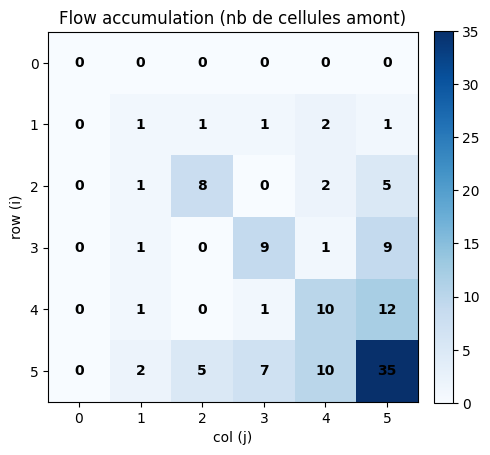

In [5]:
def flow_accumulation(d):
    # qui coule vers qui : inflow[c] = liste des cellules qui s'ecoulent dans c
    inflow = {(i, j): [] for i in range(nrows) for j in range(ncols)}
    for i in range(nrows):
        for j in range(ncols):
            t = downstream(i, j, d)
            if t is not None:
                inflow[t].append((i, j))
    acc = np.full((nrows, ncols), -1)
    def calc(c):
        if acc[c] >= 0:
            return acc[c]
        s = 0
        for n in inflow[c]:
            s += calc(n) + 1
        acc[c] = s
        return s
    for i in range(nrows):
        for j in range(ncols):
            calc((i, j))
    return acc, inflow

acc, inflow = flow_accumulation(direction)
print("Accumulation (exutoire =", acc.max(), ") :"); print(acc)
montre(acc, "Flow accumulation (nb de cellules amont)", cmap="Blues")


## Étape 5 — Stream Definition (extraction du réseau)

Une cellule est une **rivière** si elle draine assez d'amont : `accumulation >= seuil`. En dessous = versant.
Le seuil règle la **densité** du réseau : petit seuil → réseau touffu ; grand seuil → seuls les gros cours d'eau.

~~Dans tes notes IPH le seuil est **1000 cellules** (sur un vrai MNT de millions de cellules).~~
**RETIRÉ le 2026-08-19 — montré, non cité comme valeur courante.** Source privée non vérifiable, et ce n'est pas le
seuil retenu. Le seuil réellement utilisé est une **aire drainée**, pas un nombre de cellules :
`STREAM_THR = 100 km²` dans `notebooks/07_preprocessing_minibacias.ipynb` (sortie exécutée : `52,757 river cells
with STREAM_THR = 100 km2`). L'équivalent en cellules dépend de l'échelle de la grille, ce qui est précisément
pourquoi le paramètre est défini en km². Ici, sur 36 cellules,
on prend un seuil-jouet de **6** pour voir un réseau cohérent.


Reseau (acc >= 6) :
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 1]
 [0 0 0 0 1 1]
 [0 0 0 1 1 1]]


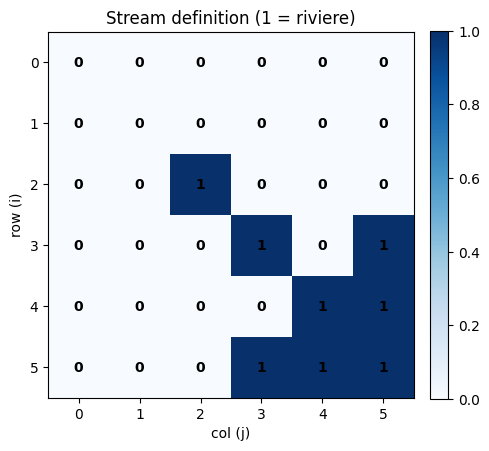

In [6]:
def stream_definition(acc, seuil):
    return acc >= seuil

seuil = 6
st = stream_definition(acc, seuil)
print("Reseau (acc >= %d) :" % seuil); print(st.astype(int))
montre(st.astype(int), "Stream definition (1 = riviere)", cmap="Blues")


## Étape 6 — Stream Segmentation (découpage en tronçons)

On coupe le réseau en **tronçons** (reaches) aux **confluences**. Pour cela on compte, pour chaque cellule de rivière,
combien de ses voisines-rivière s'y jettent :

- **0** → *source* (début de tronçon) ;
- **1** → *continuation* (on prolonge le tronçon) ;
- **≥2** → *confluence* (fin des tronçons amont, début d'un nouveau).

On part de chaque source, on descend tant que la cellule suivante est une continuation, et on stoppe à une confluence.
Chaque tronçon reçoit un identifiant. (Sur le vrai modèle, ces tronçons portent l'ordre de Strahler.)


Tronçons :
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 2]
 [0 0 0 0 1 2]
 [0 0 0 3 3 4]]


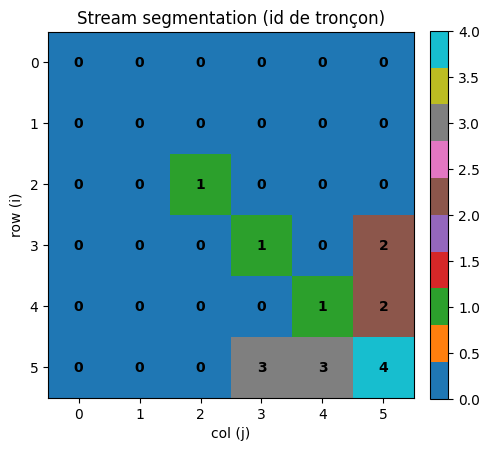

In [7]:
def stream_inflow(c, inflow, st):
    return sum(1 for n in inflow[c] if st[n])

def segmentation(d, st, inflow):
    seg = np.zeros((nrows, ncols), dtype=int)
    cells = [(i, j) for i in range(nrows) for j in range(ncols) if st[i][j]]
    debuts = [c for c in cells if stream_inflow(c, inflow, st) != 1]   # sources (0) et confluences (>=2)
    sid = 0
    for s in debuts:
        sid += 1
        c = s; seg[c] = sid
        while True:
            t = downstream(*c, d)
            if t is None or not st[t]:
                break
            if stream_inflow(t, inflow, st) != 1:   # on atteint une confluence -> nouveau tronçon
                break
            seg[t] = sid; c = t
    return seg

seg = segmentation(direction, st, inflow)
print("Tronçons :"); print(seg)
montre(seg, "Stream segmentation (id de tronçon)", cmap="tab10")


## Étape 7 — Watershed / Catchment : les minibacias

Dernière étape : à chaque **tronçon** on associe son **bassin local** = toutes les cellules de versant qui s'y déversent.
Pour chaque cellule, on suit le fil de l'eau vers l'aval jusqu'à toucher une cellule de rivière ; l'identifiant de tronçon
atteint devient la **minibacia** de la cellule.

Ces minibacias sont les **unités de calcul du MGB** : c'est sur chacune que MUSLE calcule l'érosion, et elles sont reliées
par la topologie amont→aval du réseau. ~~Dans QGIS, cette table devient le fichier **`mini.gtb`**.~~
**RETIRÉ le 2026-08-19 — montré, non cité comme état courant** : `mini.gtb` n'a **jamais** été produit
(`docs/03_methodology.md` §1c est toujours *TODO*). La table livrée est `data/processed/minibacias.csv`
(`id, area_km2, downstream` ; **8,672 lignes, 257,096.93 km²**), écrite par
`notebooks/07_preprocessing_minibacias.ipynb` et lue directement par `src/mgb_hydrology.py` (`build_topology`) et
par le moteur sédimentaire `src/mgb_sediment.py`.


Minibacias :
[[1 1 2 2 2 2]
 [1 1 1 2 2 2]
 [1 1 1 2 2 2]
 [3 1 3 1 2 2]
 [3 3 3 3 1 2]
 [3 3 3 3 3 4]]
Nombre de minibacias : 4


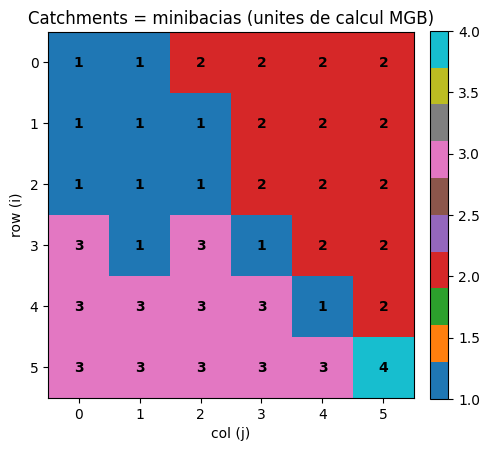

In [8]:
def catchments(d, st, seg):
    catch = np.zeros((nrows, ncols), dtype=int)
    memo = {}
    def reach(c):
        if c in memo:
            return memo[c]
        if st[c]:
            memo[c] = seg[c]; return seg[c]
        t = downstream(*c, d)
        r = reach(t) if t is not None else 0
        memo[c] = r; return r
    for i in range(nrows):
        for j in range(ncols):
            catch[i][j] = reach((i, j))
    return catch

catch = catchments(direction, st, seg)
print("Minibacias :"); print(catch)
print("Nombre de minibacias :", catch.max())
montre(catch, "Catchments = minibacias (unites de calcul MGB)", cmap="tab10")


## Du DEM-jouet au vrai Magdalena

> **Ce qui a réellement été fait — note datée 2026-08-19.** La liste ci-dessous est le **plan du 2026-07-27**. Elle
> est **conservée telle quelle comme trace**, mais cinq de ses affirmations ont été dépassées :
>
> | affirmation du plan ci-dessous | ce qui a été fait |
> |---|---|
> | « la logique est **exactement la même** » | vrai pour les étapes 2-4 (Planchon-Darboux, D8) ; **faux pour 5 et 7** — le seuil réel est une **aire** et non un compte de cellules, et les minibacias réelles sont contraintes par une cible (`N_TARGET = 12000`, réalisé **8,672**) **et** par le forçage de chaque station de débit comme exutoire de minibacia (`notebooks/07`, étape 5b) |
> | ALOS World 3D 30 m / Copernicus GLO-30 | **Copernicus GLO-90 (COP90)** (`docs/15_domain_correction.md`). Le `cellsize = 30.0` de la cellule de code est une valeur **jouet**, pas le MNT du projet |
> | limite ~250 M cellules → sous-bassin ou résolution dégradée, « une de tes 3 questions ouvertes » | **question RÉSOLUE**, stampée 2026-08-12 (`docs/open_questions.md` Q3) : *« the pilot-first route was not taken: the whole basin was built directly at 90 m »* — **8,672 minibacias, 257,096.93 km²** |
> | seuil réel **1000 cellules** | `STREAM_THR = **100 km²**` d'aire drainée (`notebooks/07`) — un seuil d'**aire** |
> | export en **`mini.gtb`** | jamais produit (`docs/03_methodology.md` §1c reste *TODO*) ; le livrable est `data/processed/minibacias.csv` |
> | « IPH-HydroTools … juste optimisés en Fortran » | la délinéation a été faite en **Python pur** (`pyflwdir`), sans QGIS |

La logique est **exactement la même** à l'échelle réelle ; seuls changent la taille et l'outil :

- **Étape 1** : remplacer notre matrice 6×6 par le `.asc` du vrai MNT (ALOS World 3D 30 m ou Copernicus GLO-30),
  `NODATA_value` forcé à **-9999**. ⚠️ Le Magdalena entier à 30 m dépasse la limite ~250 M cellules d'IPH-HydroTools
  → travailler sur un **sous-bassin** ou dégrader la résolution (une de tes 3 questions ouvertes).
- **Étapes 2-4** : identiques ; IPH-HydroTools utilise les mêmes algorithmes (Planchon-Darboux, D8), juste optimisés en Fortran.
- **Étape 5** : seuil réel **1000 cellules** (au lieu de 6).
- **Étapes 6-7** : les minibacias produites sont exportées en **`mini.gtb`**, format d'entrée du MGB.

**Ensuite (hors de ce notebook)** : croisement sols × occupation → **URH**, puis calage **hydrologique** (débits IDEAM),
~~puis calage **sédimentaire** (α, β de MUSLE) par la technique des seuils pluie/pente de Fagundes et al.~~
**RETIRÉ le 2026-08-19 — montré, non cité comme plan courant.** La technique des seuils pluie/pente n'a jamais été
mise en œuvre. La chaîne réellement suivie, et ce que ce notebook alimente :
`07` (délinéation) → `08` (URH, **24 types**) → `09` (paramètres sol) → `12` (assemblage) → `13`/`14` (run de base
et calage hydrologique) → `18` (construction MUSLE) → `19` (porte C3, entrée C4).
La **phase B a clôturé sur la configuration H2E** (`F = 0.25931`, 2009-2018, 63 stations), plafonnée par le champ de
pluie (`r ≈ 0.57`) et **non** par un paramètre (`docs/22`, `docs/26`, `docs/58`). Le calage sédimentaire C4.3 est
**RAILED / EXPLORATOIRE, non adopté** — α et β ne sont pas des paramètres ajustés que l'on peut citer, et seul le
produit Π est identifiable (`docs/55`, `docs/42`). Le résultat de tête est **C5** : le modèle **reproduit** le
contraste ENSO observé — **18/18 stations**, rapport médian de taux **3.05×** (1.62-4.85), face à **22/22** dans les
observations (`docs/56`, `docs/34`). **La phase C est TERMINÉE.**

Ce notebook n'implémente pas ces algorithmes pour *remplacer* IPH-HydroTools, mais pour que chaque case de la chaîne
soit une boîte transparente et non une boîte noire.
